### Exploração inicial `SLCE3`. Quais relações podemos identificar?

#### Apresentação e tratamento

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

# Exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais sobre o DataFrame
print("\nInformações gerais do DataFrame:")
print(df.info())


# Verifica se há valores negativos nas colunas 'Close' e 'Open'
print("\nVerificando valores negativos nas colunas 'Close' e 'Open':")
negative_close = df[df['Close'] < 0]
negative_open = df[df['Open'] < 0]
negative_high = df[df['High'] < 0]
negative_low = df[df['Low'] < 0]
negative_volum = df[df['Volume'] < 0]

if negative_close.empty:
    print("\nNão há valores negativos na coluna 'Close'.")

if negative_open.empty:
    print("Não há valores negativos na coluna 'Open'.")

if negative_high.empty:
    print("Não há valores negativos na coluna 'High'.")

if negative_low.empty:
    print("Não há valores negativos na coluna 'Low'.")

if negative_volum.empty:
    print("Não há valores negativos na coluna 'Volume'.")

Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None

Verificando valores negativos nas colunas 'Close' e 'Open':

Não há valores negativo

#### Adicionando colunas de valores futuros

In [55]:
df['Close_Open_Diff'] = df['Close'] - df['Open']

print("Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':")
print(df.head())

sns.set_style("whitegrid")

print("\nEstatísticas descritivas do DataFrame (com 'Close_Open_Diff'):")
print(df.describe())

df['Close_1d_fut'] = df['Close'].shift(-1)
df['Close_3d_fut'] = df['Close'].shift(-3)
df['Close_7d_fut'] = df['Close'].shift(-7)
df['Close_15d_fut'] = df['Close'].shift(-15)
df['Close_30d_fut'] = df['Close'].shift(-30)
df['Volume_1d_fut'] = df['Volume'].shift(-1)
df['Volume_3d_fut'] = df['Volume'].shift(-3)
df['Volume_7d_fut'] = df['Volume'].shift(-7)
df['Volume_15d_fut'] = df['Volume'].shift(-15)
df['Volume_30d_fut'] = df['Volume'].shift(-30)

print("\nPrimeiras linhas com colunas de fechamento futuro:")
print(df[['Close', 'Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']].head(35))

df_process = df.dropna(subset=['Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']).copy()

# df_process.to_csv('SLCE3_process.csv', index=False)
# print("DataFrame processado salvo como 'SLCE3_process.csv'.")


Primeiras 5 linhas do DataFrame com a nova coluna 'Close_Open_Diff':
         Date     Close      High       Low      Open   Volume  \
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908   
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536   
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724   
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248   
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172   

   Close_Open_Diff  
0         0.105752  
1         0.026716  
2        -0.012245  
3         0.012245  
4        -0.016698  

Estatísticas descritivas do DataFrame (com 'Close_Open_Diff'):
             Close         High          Low         Open        Volume  \
count  1738.000000  1738.000000  1738.000000  1738.000000  1.738000e+03   
mean     12.853513    13.075743    12.651012    12.864267  3.029539e+06   
std       5.343477     5.411924     5.279755     5.346681  1.646280e+06   
min       3.077934     3.103537     2.972182

#### Valor de fechamento em função do tempo.


Gráfico 'Preço de Fechamento ao Longo do Tempo' salvo como 'close_price_over_time_full.png'


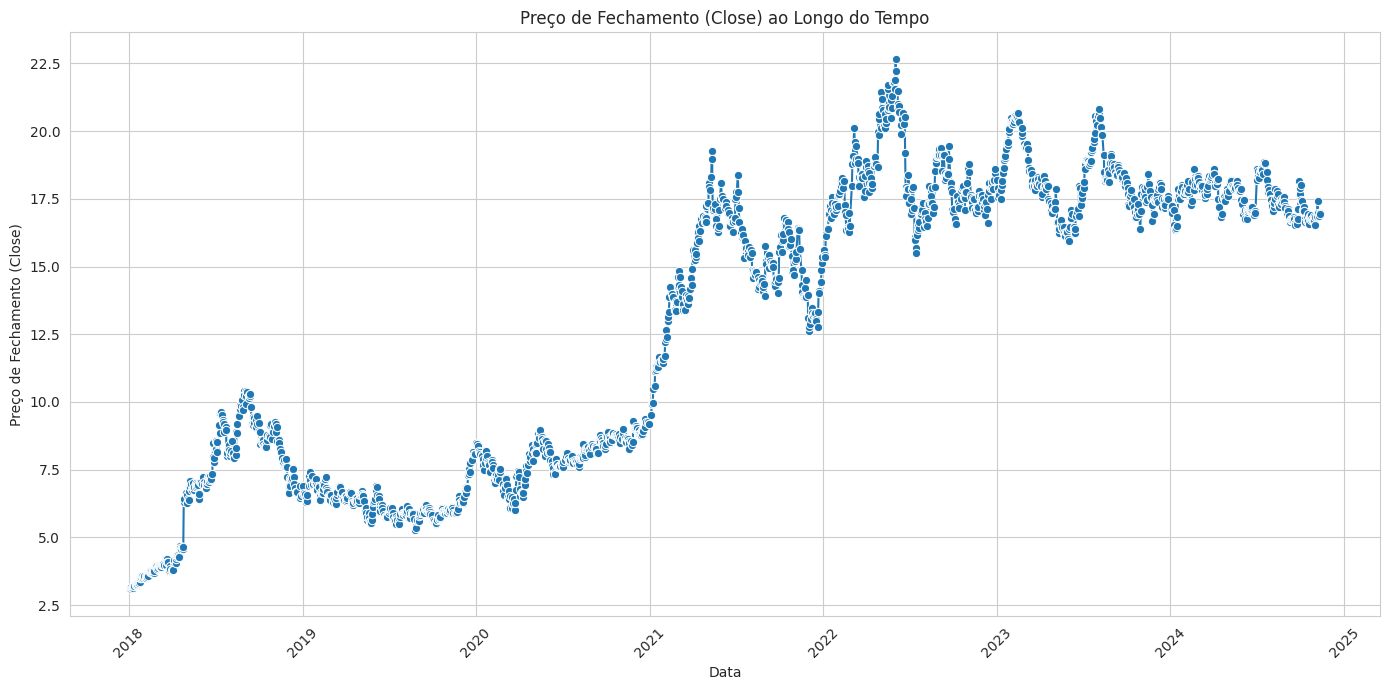

In [56]:
df_process['Date'] = pd.to_datetime(df_process['Date'])
df_process.set_index('Date', inplace=True)

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_process.index, y=df_process['Close'], marker='o', linestyle='-')
plt.title('Preço de Fechamento (Close) ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('close_price_over_time_full.png')
print("\nGráfico 'Preço de Fechamento ao Longo do Tempo' salvo como 'close_price_over_time_full.png'")


#### Analise aprofundada de 2021


Gráfico 'Preço de Fechamento 2021 e 2022' salvo como 'close_price_2021_2022.png'


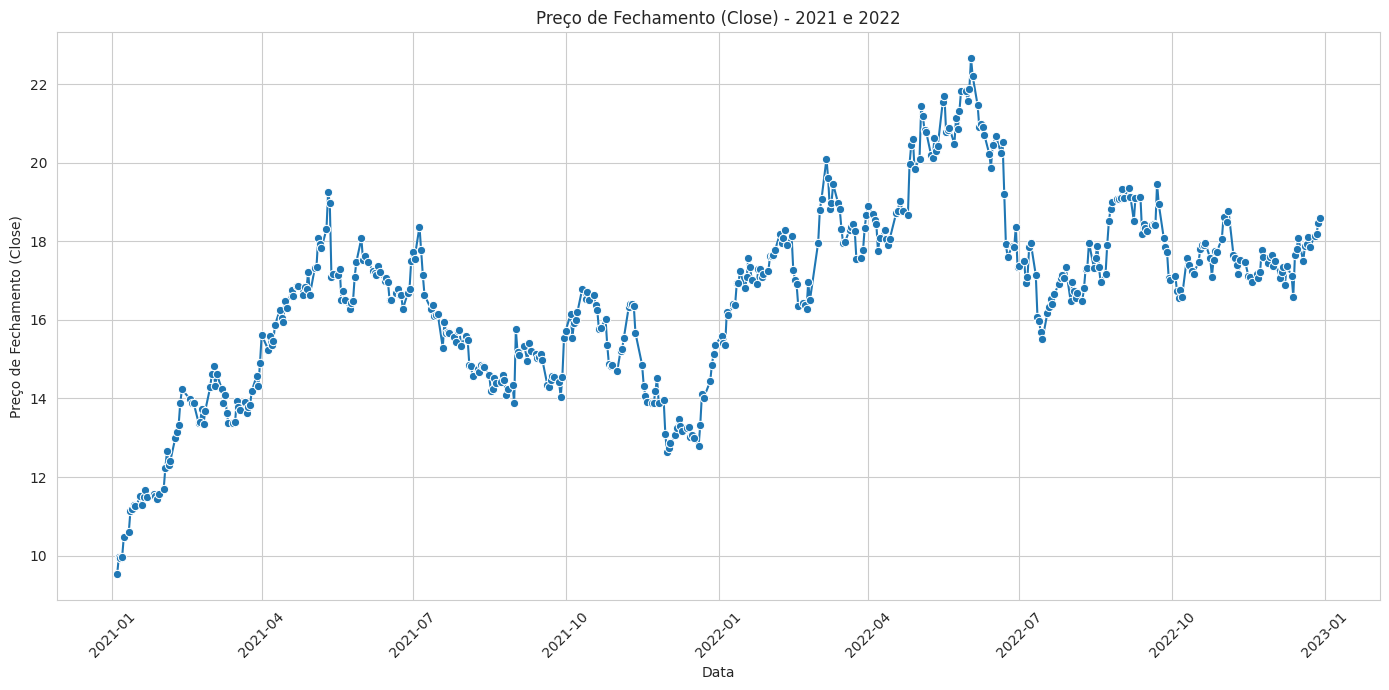

In [57]:
# Garante que o índice é DatetimeIndex
if not isinstance(df_process.index, pd.DatetimeIndex):
	df_process.index = pd.to_datetime(df_process.index)

df_2021_2022 = df_process.loc[(df_process.index.year >= 2021) & (df_process.index.year <= 2022)]

plt.figure(figsize=(14, 7))
sns.lineplot(x=df_2021_2022.index, y=df_2021_2022['Close'], marker='o', linestyle='-')
plt.title('Preço de Fechamento (Close) - 2021 e 2022')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento (Close)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('close_price_2021_2022.png')
print("\nGráfico 'Preço de Fechamento 2021 e 2022' salvo como 'close_price_2021_2022.png'")



#### Adicionando variaveis dicotômicas para 2021-05-05 e 2022-02-07

In [58]:
# Criação da variável dicotômica categórica
# 0: antes de 2021-05-05
# 1: entre 2021-05-05 e 2022-02-07 
# 2: após 2022-02-07
df_process['dummy_period'] = 0
df_process.loc[df_process.index >= pd.to_datetime('2021-05-05'), 'dummy_period'] = 1
df_process.loc[df_process.index >= pd.to_datetime('2022-02-07'), 'dummy_period'] = 2

df_process.to_csv('SLCE3_process_dicotomic.csv', index=True)
print("DataFrame salvo como 'SLCE3_process_dicotomic.csv'.")
print(f"Distribuição da variável dummy_period:")
print(df_process['dummy_period'].value_counts().sort_index())

DataFrame salvo como 'SLCE3_process_dicotomic.csv'.
Distribuição da variável dummy_period:
dummy_period
0    824
1    190
2    694
Name: count, dtype: int64


#### Treinando o medelo de regressão linear simples com 2 variaveis dicotômicas Close x Low para 30 dias no futuro


Gráfico salvo como 'regressao_low_dummies_close_30d_fut.png'

Matriz de correlação salva como 'correlacao_low_dummies_close_30d_fut.png'

Métricas do Modelo com Dummy Period (Close_30d_fut):
Coeficientes: [0.89597255 0.31308219]
Intercepto: 1.4641
R-quadrado (R²): 0.9159
Erro Absoluto Médio (MAE): 1.2018


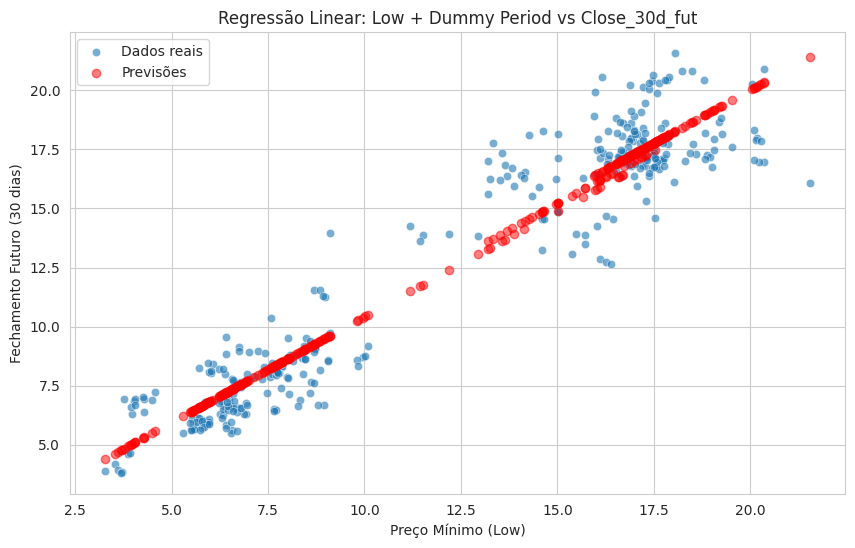

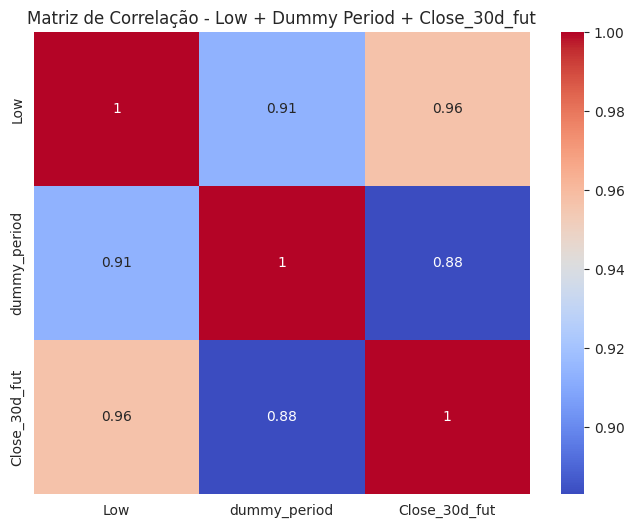

In [59]:
# Regressão Close_30d_fut ~ Low + dummy_period
y_30d = df_process['Close_30d_fut']
X = df_process[['Low', 'dummy_period']]
X_train, X_test, y_train_30d, y_test_30d = train_test_split(X, y_30d, test_size=0.2, random_state=42)
model_30d = LinearRegression()
model_30d.fit(X_train, y_train_30d)
y_pred_30d = model_30d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Low'], y=y_test_30d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Low'], y_pred_30d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Low + Dummy Period vs Close_30d_fut')
plt.xlabel('Preço Mínimo (Low)')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_low_dummies_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_low_dummies_close_30d_fut.png'")

# Matriz de correlação
corr_matrix = df_process[['Low', 'dummy_period', 'Close_30d_fut']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - Low + Dummy Period + Close_30d_fut')
plt.savefig('correlacao_low_dummies_close_30d_fut.png')
print("\nMatriz de correlação salva como 'correlacao_low_dummies_close_30d_fut.png'")

# Métricas
mae_low = mean_absolute_error(y_test_30d, y_pred_30d)
print("\nMétricas do Modelo com Dummy Period (Close_30d_fut):")
print(f"Coeficientes: {model_30d.coef_}")
print(f"Intercepto: {model_30d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_30d.score(X_test, y_test_30d):.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_low:.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x High para 30 dias no futuro


Gráfico salvo como 'regressao_high_dummies_close_30d_fut.png'

Matriz de correlação salva como 'correlacao_high_dummies_close_30d_fut.png'

Métricas do Modelo com Dummy Period (High, Close_30d_fut):
Coeficientes: [0.85333685 0.4436734 ]
Intercepto: 1.5166
R-quadrado (R²): 0.9166
Erro Absoluto Médio (MAE): 1.1913


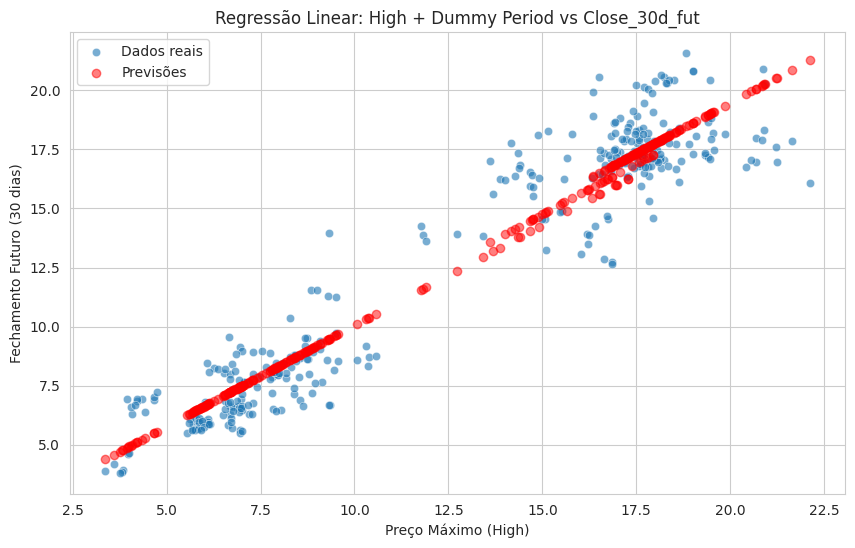

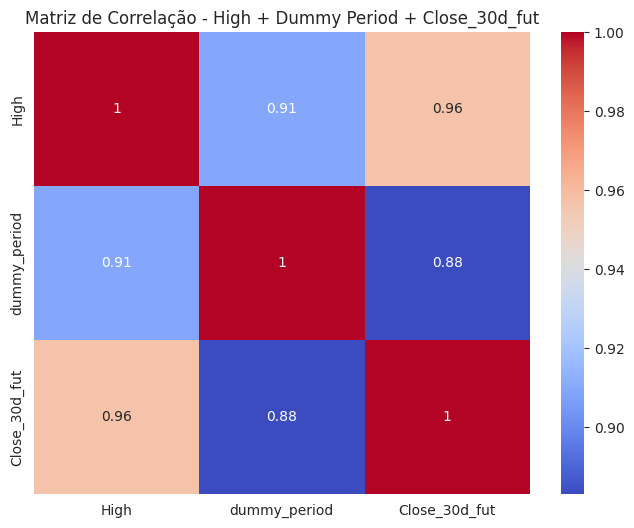

In [60]:
# Regressão Close_30d_fut ~ High + dummy_period
y_30d = df_process['Close_30d_fut']
X = df_process[['High', 'dummy_period']]
X_train, X_test, y_train_30d, y_test_30d = train_test_split(X, y_30d, test_size=0.2, random_state=42)
model_30d = LinearRegression()
model_30d.fit(X_train, y_train_30d)
y_pred_30d = model_30d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['High'], y=y_test_30d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['High'], y_pred_30d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: High + Dummy Period vs Close_30d_fut')
plt.xlabel('Preço Máximo (High)')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_high_dummies_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_high_dummies_close_30d_fut.png'")

# Matriz de correlação
corr_matrix = df_process[['High', 'dummy_period', 'Close_30d_fut']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - High + Dummy Period + Close_30d_fut')
plt.savefig('correlacao_high_dummies_close_30d_fut.png')
print("\nMatriz de correlação salva como 'correlacao_high_dummies_close_30d_fut.png'")

# Métricas
mae_high = mean_absolute_error(y_test_30d, y_pred_30d)
print("\nMétricas do Modelo com Dummy Period (High, Close_30d_fut):")
print(f"Coeficientes: {model_30d.coef_}")
print(f"Intercepto: {model_30d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_30d.score(X_test, y_test_30d):.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_high:.4f}")

#### Treinando o modelo de regressão linear simples com 2 variáveis dicotômicas Close x Open para 30 dias no futuro


Gráfico salvo como 'regressao_open_dummies_close_30d_fut.png'

Matriz de correlação salva como 'correlacao_open_dummies_close_30d_fut.png'

Métricas do Modelo com Dummy Period (Open, Close_30d_fut):
Coeficientes: [0.87116659 0.39488235]
Intercepto: 1.5158
R-quadrado (R²): 0.9134
Erro Absoluto Médio (MAE): 1.2170


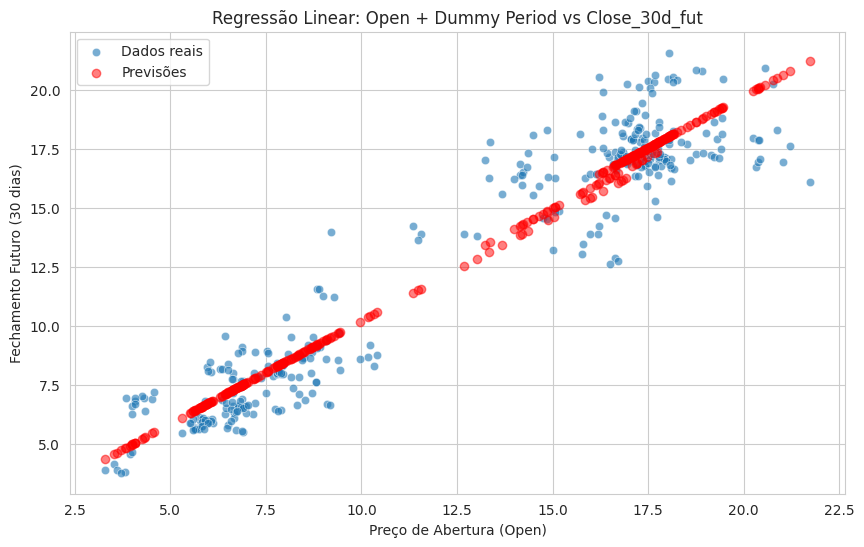

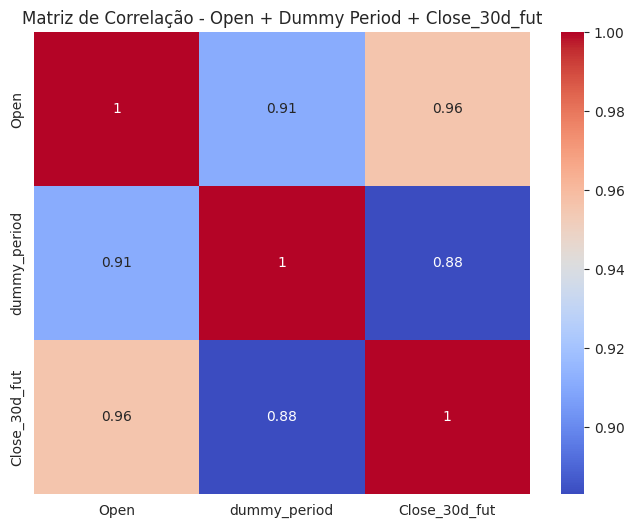

In [61]:
# Regressão Close_30d_fut ~ Open + dummy_period
y_30d = df_process['Close_30d_fut']
X = df_process[['Open', 'dummy_period']]
X_train, X_test, y_train_30d, y_test_30d = train_test_split(X, y_30d, test_size=0.2, random_state=42)
model_30d = LinearRegression()
model_30d.fit(X_train, y_train_30d)
y_pred_30d = model_30d.predict(X_test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Open'], y=y_test_30d, alpha=0.6, label='Dados reais')
plt.scatter(X_test['Open'], y_pred_30d, color='red', alpha=0.5, label='Previsões')
plt.title('Regressão Linear: Open + Dummy Period vs Close_30d_fut')
plt.xlabel('Preço de Abertura (Open)')
plt.ylabel('Fechamento Futuro (30 dias)')
plt.legend()
plt.grid(True)
plt.savefig('regressao_open_dummies_close_30d_fut.png')
print("\nGráfico salvo como 'regressao_open_dummies_close_30d_fut.png'")

# Matriz de correlação
corr_matrix = df_process[['Open', 'dummy_period', 'Close_30d_fut']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação - Open + Dummy Period + Close_30d_fut')
plt.savefig('correlacao_open_dummies_close_30d_fut.png')
print("\nMatriz de correlação salva como 'correlacao_open_dummies_close_30d_fut.png'")

# Métricas
mae_open = mean_absolute_error(y_test_30d, y_pred_30d)
print("\nMétricas do Modelo com Dummy Period (Open, Close_30d_fut):")
print(f"Coeficientes: {model_30d.coef_}")
print(f"Intercepto: {model_30d.intercept_:.4f}")
print(f"R-quadrado (R²): {model_30d.score(X_test, y_test_30d):.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_open:.4f}")

#### Regressão linear multipla (low, high e open)

REGRESSÃO MÚLTIPLA SEM VARIÁVEIS DICOTÔMICAS

1. MODELO PARA CLOSE 7 DIAS NO FUTURO


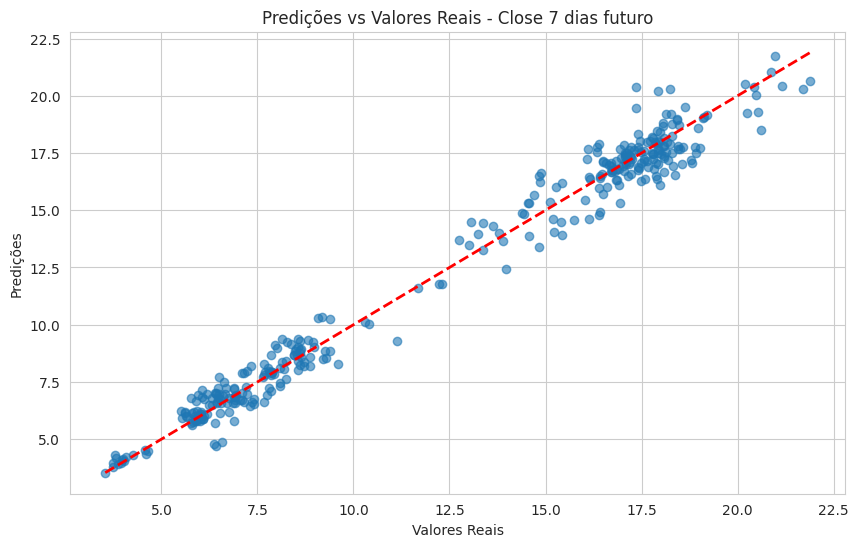


Gráfico salvo como 'regressao_multipla_sem_dummy_close_7_dias_futuro.png'

Métricas do Modelo - Close 7 dias futuro:
Coeficientes (Low, High, Open): [ 0.65102402  0.65967095 -0.32771859]
Intercepto: 0.2572
R-quadrado (R²): 0.9798
Erro Absoluto Médio (MAE): 0.5687

2. MODELO PARA CLOSE 15 DIAS NO FUTURO


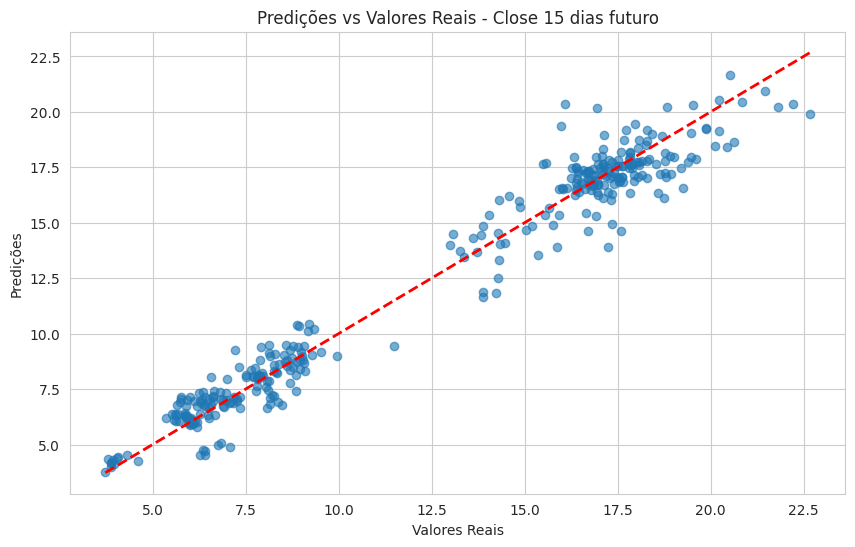


Gráfico salvo como 'regressao_multipla_sem_dummy_close_15_dias_futuro.png'

Métricas do Modelo - Close 15 dias futuro:
Coeficientes (Low, High, Open): [ 0.69091144  0.57919814 -0.30230469]
Intercepto: 0.5417
R-quadrado (R²): 0.9637
Erro Absoluto Médio (MAE): 0.7477

3. MODELO PARA CLOSE 30 DIAS NO FUTURO


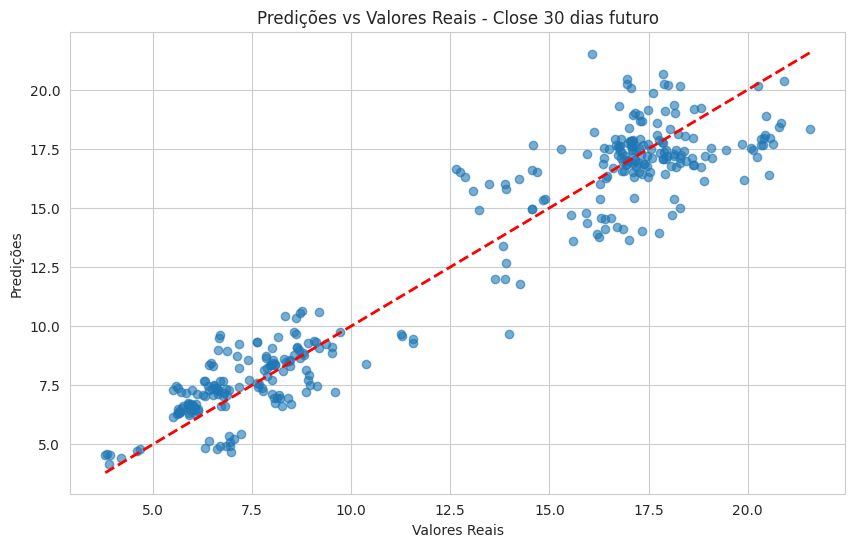


Gráfico salvo como 'regressao_multipla_sem_dummy_close_30_dias_futuro.png'

Métricas do Modelo - Close 30 dias futuro:
Coeficientes (Low, High, Open): [ 0.67506904  0.41903703 -0.15523381]
Intercepto: 1.0707
R-quadrado (R²): 0.9161
Erro Absoluto Médio (MAE): 1.1824


In [62]:
# Regressão Múltipla SEM variáveis dicotômicas: Low + High + Open para predições futuras
print("=" * 60)
print("REGRESSÃO MÚLTIPLA SEM VARIÁVEIS DICOTÔMICAS")
print("=" * 60)

# Definindo as variáveis independentes (sem dummy_period)
X_multiple = df_process[['Low', 'High', 'Open']]

# Função para treinar e avaliar modelos
def train_and_evaluate_model(X, y, target_name, save_prefix):
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    r2 = model.score(X_test, y_test)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Criar gráfico de predições vs valores reais
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Valores Reais')
    plt.ylabel('Predições')
    plt.title(f'Predições vs Valores Reais - {target_name}')
    plt.grid(True)
    plt.savefig(f'{save_prefix}_{target_name.lower().replace(" ", "_")}.png')
    plt.show()
    print(f"\nGráfico salvo como '{save_prefix}_{target_name.lower().replace(' ', '_')}.png'")
    
    # Imprimir métricas
    print(f"\nMétricas do Modelo - {target_name}:")
    print(f"Coeficientes (Low, High, Open): {model.coef_}")
    print(f"Intercepto: {model.intercept_:.4f}")
    print(f"R-quadrado (R²): {r2:.4f}")
    print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
    
    return model, r2, mae

# Treinar modelos para diferentes horizontes temporais
print("\n1. MODELO PARA CLOSE 7 DIAS NO FUTURO")
model_7d, r2_7d, mae_7d = train_and_evaluate_model(
    X_multiple, df_process['Close_7d_fut'], 
    "Close 7 dias futuro", "regressao_multipla_sem_dummy"
)

print("\n2. MODELO PARA CLOSE 15 DIAS NO FUTURO")
model_15d, r2_15d, mae_15d = train_and_evaluate_model(
    X_multiple, df_process['Close_15d_fut'], 
    "Close 15 dias futuro", "regressao_multipla_sem_dummy"
)

print("\n3. MODELO PARA CLOSE 30 DIAS NO FUTURO")
model_30d, r2_30d, mae_30d = train_and_evaluate_model(
    X_multiple, df_process['Close_30d_fut'], 
    "Close 30 dias futuro", "regressao_multipla_sem_dummy"
)


REGRESSÃO MÚLTIPLA COM VARIÁVEIS DICOTÔMICAS

1. MODELO COM DUMMY PARA CLOSE 7 DIAS NO FUTURO


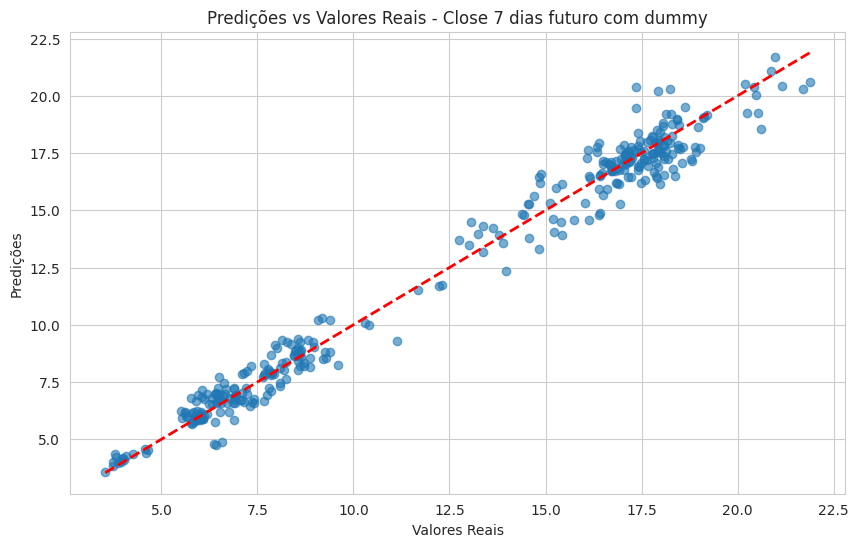


Gráfico salvo como 'regressao_multipla_com_dummy_close_7_dias_futuro_com_dummy.png'

Métricas do Modelo - Close 7 dias futuro com dummy:
Coeficientes (Low, High, Open): [ 0.60250928  0.69526634 -0.32990057  0.08717732]
Intercepto: 0.3514
R-quadrado (R²): 0.9798
Erro Absoluto Médio (MAE): 0.5711

2. MODELO COM DUMMY PARA CLOSE 15 DIAS NO FUTURO


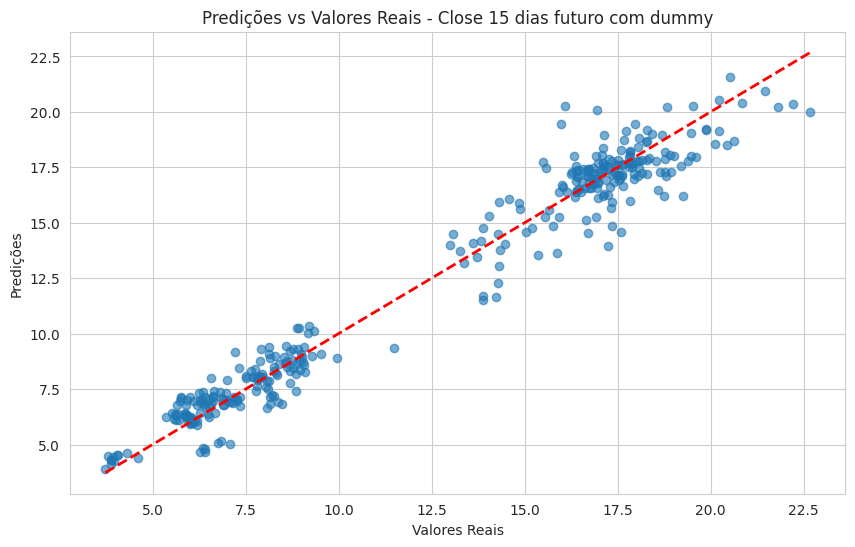


Gráfico salvo como 'regressao_multipla_com_dummy_close_15_dias_futuro_com_dummy.png'

Métricas do Modelo - Close 15 dias futuro com dummy:
Coeficientes (Low, High, Open): [ 0.55083589  0.68197194 -0.30860469  0.25170519]
Intercepto: 0.8136
R-quadrado (R²): 0.9636
Erro Absoluto Médio (MAE): 0.7497

3. MODELO COM DUMMY PARA CLOSE 30 DIAS NO FUTURO


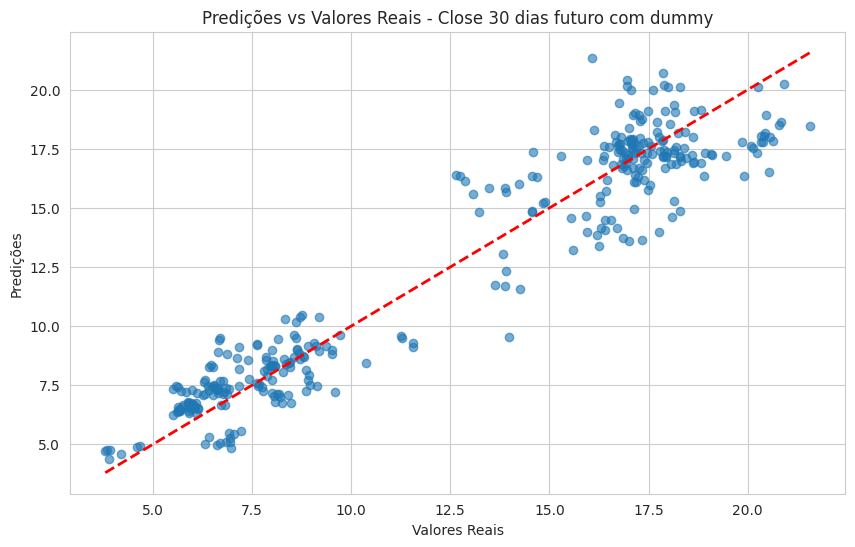


Gráfico salvo como 'regressao_multipla_com_dummy_close_30_dias_futuro_com_dummy.png'

Métricas do Modelo - Close 30 dias futuro com dummy:
Coeficientes (Low, High, Open): [ 0.46373484  0.5740935  -0.16473872  0.37975162]
Intercepto: 1.4810
R-quadrado (R²): 0.9170
Erro Absoluto Médio (MAE): 1.1903


In [63]:
# Regressão Múltipla COM variáveis dicotômicas: Low + High + Open + dummy_period
print("\n" + "=" * 60)
print("REGRESSÃO MÚLTIPLA COM VARIÁVEIS DICOTÔMICAS")
print("=" * 60)

# Definindo as variáveis independentes (com dummy_period)
X_multiple_dummy = df_process[['Low', 'High', 'Open', 'dummy_period']]

# Treinar modelos para diferentes horizontes temporais COM dummy variables
print("\n1. MODELO COM DUMMY PARA CLOSE 7 DIAS NO FUTURO")
model_7d_dummy, r2_7d_dummy, mae_7d_dummy = train_and_evaluate_model(
    X_multiple_dummy, df_process['Close_7d_fut'], 
    "Close 7 dias futuro com dummy", "regressao_multipla_com_dummy"
)

print("\n2. MODELO COM DUMMY PARA CLOSE 15 DIAS NO FUTURO")
model_15d_dummy, r2_15d_dummy, mae_15d_dummy = train_and_evaluate_model(
    X_multiple_dummy, df_process['Close_15d_fut'], 
    "Close 15 dias futuro com dummy", "regressao_multipla_com_dummy"
)

print("\n3. MODELO COM DUMMY PARA CLOSE 30 DIAS NO FUTURO")
model_30d_dummy, r2_30d_dummy, mae_30d_dummy = train_and_evaluate_model(
    X_multiple_dummy, df_process['Close_30d_fut'], 
    "Close 30 dias futuro com dummy", "regressao_multipla_com_dummy"
)


COMPARAÇÃO DOS RESULTADOS

Tabela Comparativa dos Modelos:
  Horizonte  R² Sem Dummy  R² Com Dummy  MAE Sem Dummy  MAE Com Dummy  \
0    7 dias        0.9798        0.9798         0.5687         0.5711   
1   15 dias        0.9637        0.9636         0.7477         0.7497   
2   30 dias        0.9161        0.9170         1.1824         1.1903   

   Melhoria R²  Melhoria MAE  
0      -0.0001       -0.0024  
1      -0.0002       -0.0020  
2       0.0008       -0.0079  


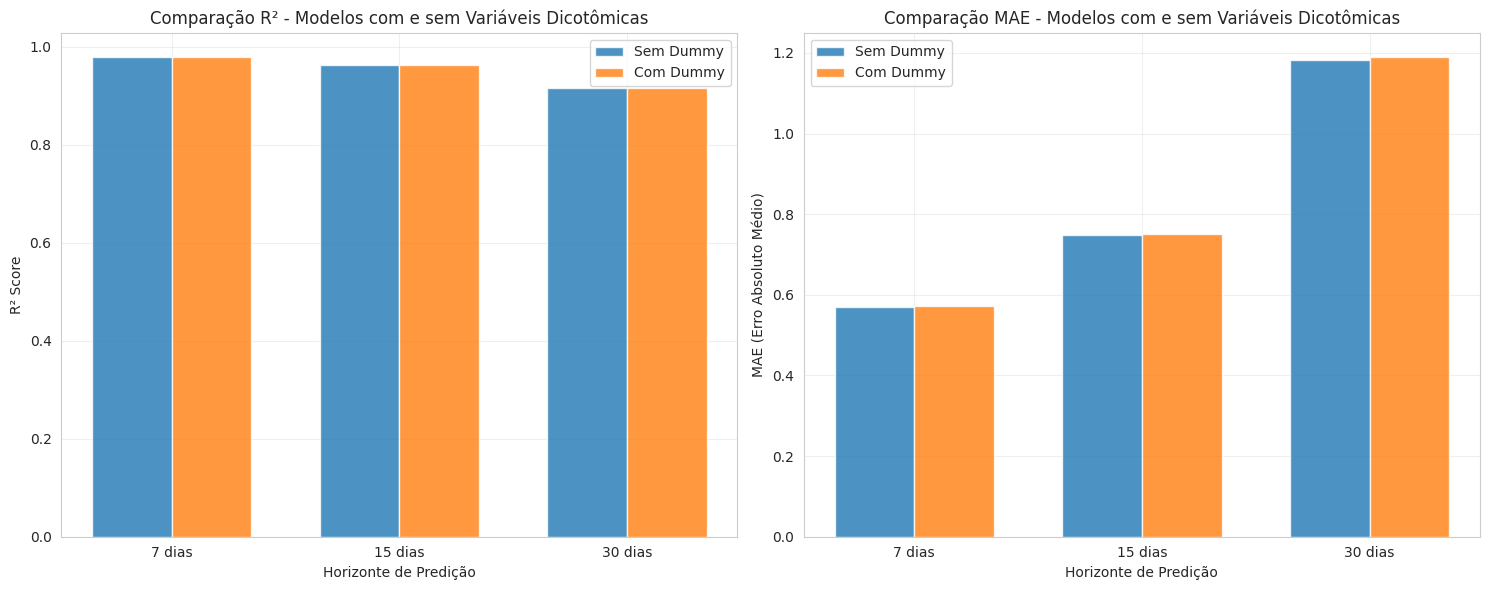


Gráfico de comparação salvo como 'comparacao_modelos_multiplos.png'

ANÁLISE DOS RESULTADOS

7 DIAS:
  - Melhoria no R²: -0.0001 (-0.01%)
  - Redução no MAE: -0.0024 (-0.43%)
  ✗ Variáveis dicotômicas PIORAM a capacidade preditiva

15 DIAS:
  - Melhoria no R²: -0.0002 (-0.02%)
  - Redução no MAE: -0.0020 (-0.27%)
  ✗ Variáveis dicotômicas PIORAM a capacidade preditiva

30 DIAS:
  - Melhoria no R²: 0.0008 (+0.09%)
  - Redução no MAE: -0.0079 (-0.67%)
  ✓ Variáveis dicotômicas MELHORAM a capacidade preditiva

Resultados salvos em 'comparacao_regressao_multipla.csv'


In [64]:
# Comparação dos Resultados
print("\n" + "=" * 60)
print("COMPARAÇÃO DOS RESULTADOS")
print("=" * 60)

# Criar DataFrame para comparação
results_comparison = pd.DataFrame({
    'Horizonte': ['7 dias', '15 dias', '30 dias'],
    'R² Sem Dummy': [r2_7d, r2_15d, r2_30d],
    'R² Com Dummy': [r2_7d_dummy, r2_15d_dummy, r2_30d_dummy],
    'MAE Sem Dummy': [mae_7d, mae_15d, mae_30d],
    'MAE Com Dummy': [mae_7d_dummy, mae_15d_dummy, mae_30d_dummy]
})

# Calcular melhorias
results_comparison['Melhoria R²'] = results_comparison['R² Com Dummy'] - results_comparison['R² Sem Dummy']
results_comparison['Melhoria MAE'] = results_comparison['MAE Sem Dummy'] - results_comparison['MAE Com Dummy']

print("\nTabela Comparativa dos Modelos:")
print(results_comparison.round(4))

# Visualização da comparação
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico R²
x_pos = range(len(results_comparison))
width = 0.35

axes[0].bar([x - width/2 for x in x_pos], results_comparison['R² Sem Dummy'], 
           width, label='Sem Dummy', alpha=0.8)
axes[0].bar([x + width/2 for x in x_pos], results_comparison['R² Com Dummy'], 
           width, label='Com Dummy', alpha=0.8)
axes[0].set_xlabel('Horizonte de Predição')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Comparação R² - Modelos com e sem Variáveis Dicotômicas')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_comparison['Horizonte'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico MAE
axes[1].bar([x - width/2 for x in x_pos], results_comparison['MAE Sem Dummy'], 
           width, label='Sem Dummy', alpha=0.8)
axes[1].bar([x + width/2 for x in x_pos], results_comparison['MAE Com Dummy'], 
           width, label='Com Dummy', alpha=0.8)
axes[1].set_xlabel('Horizonte de Predição')
axes[1].set_ylabel('MAE (Erro Absoluto Médio)')
axes[1].set_title('Comparação MAE - Modelos com e sem Variáveis Dicotômicas')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(results_comparison['Horizonte'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_modelos_multiplos.png')
plt.show()
print("\nGráfico de comparação salvo como 'comparacao_modelos_multiplos.png'")

# Análise dos resultados
print("\n" + "=" * 60)
print("ANÁLISE DOS RESULTADOS")
print("=" * 60)

for i, horizonte in enumerate(['7 dias', '15 dias', '30 dias']):
    r2_melhoria = results_comparison.iloc[i]['Melhoria R²']
    mae_melhoria = results_comparison.iloc[i]['Melhoria MAE']
    
    print(f"\n{horizonte.upper()}:")
    print(f"  - Melhoria no R²: {r2_melhoria:.4f} ({(r2_melhoria/results_comparison.iloc[i]['R² Sem Dummy']*100):+.2f}%)")
    print(f"  - Redução no MAE: {mae_melhoria:.4f} ({(mae_melhoria/results_comparison.iloc[i]['MAE Sem Dummy']*100):+.2f}%)")
    
    if r2_melhoria > 0:
        print(f"  ✓ Variáveis dicotômicas MELHORAM a capacidade preditiva")
    else:
        print(f"  ✗ Variáveis dicotômicas PIORAM a capacidade preditiva")

# Salvar resultados em CSV
results_comparison.to_csv('comparacao_regressao_multipla.csv', index=False)
print(f"\nResultados salvos em 'comparacao_regressao_multipla.csv'")


ANÁLISE DETALHADA DOS COEFICIENTES

COEFICIENTES DOS MODELOS SEM VARIÁVEIS DICOTÔMICAS:
  Horizonte     Low    High    Open  Intercepto
0    7 dias  0.6510  0.6597 -0.3277      0.2572
1   15 dias  0.6909  0.5792 -0.3023      0.5417
2   30 dias  0.6751  0.4190 -0.1552      1.0707

COEFICIENTES DOS MODELOS COM VARIÁVEIS DICOTÔMICAS:
  Horizonte     Low    High    Open  Dummy_Period  Intercepto
0    7 dias  0.6025  0.6953 -0.3299        0.0872      0.3514
1   15 dias  0.5508  0.6820 -0.3086        0.2517      0.8136
2   30 dias  0.4637  0.5741 -0.1647        0.3798      1.4810


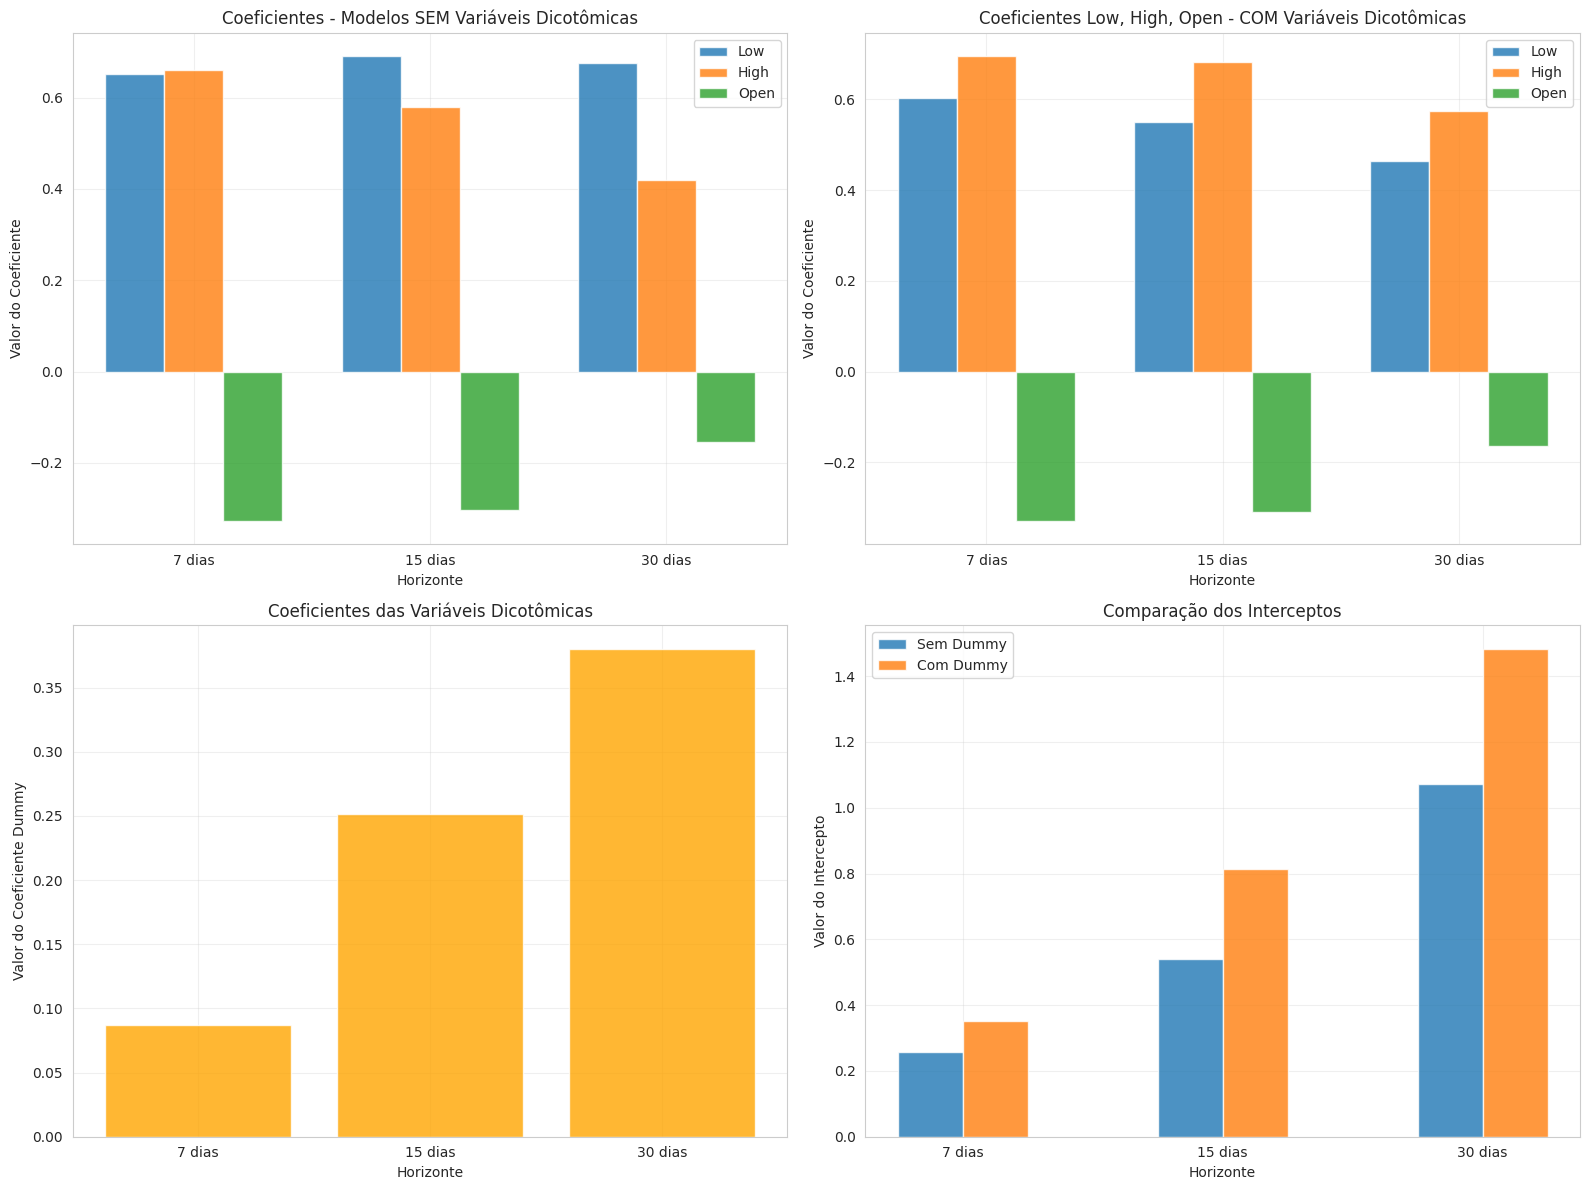


Gráfico de análise dos coeficientes salvo como 'analise_coeficientes_regressao_multipla.png'

Coeficientes salvos em 'coeficientes_sem_dummy.csv' e 'coeficientes_com_dummy.csv'


In [65]:
# Análise detalhada dos coeficientes
print("\n" + "=" * 60)
print("ANÁLISE DETALHADA DOS COEFICIENTES")
print("=" * 60)

# Criar DataFrames para os coeficientes
models_without_dummy = [model_7d, model_15d, model_30d]
models_with_dummy = [model_7d_dummy, model_15d_dummy, model_30d_dummy]
horizons = ['7 dias', '15 dias', '30 dias']

# Coeficientes sem dummy
coef_without_dummy = pd.DataFrame({
    'Horizonte': horizons,
    'Low': [model.coef_[0] for model in models_without_dummy],
    'High': [model.coef_[1] for model in models_without_dummy],
    'Open': [model.coef_[2] for model in models_without_dummy],
    'Intercepto': [model.intercept_ for model in models_without_dummy]
})

# Coeficientes com dummy
coef_with_dummy = pd.DataFrame({
    'Horizonte': horizons,
    'Low': [model.coef_[0] for model in models_with_dummy],
    'High': [model.coef_[1] for model in models_with_dummy],
    'Open': [model.coef_[2] for model in models_with_dummy],
    'Dummy_Period': [model.coef_[3] for model in models_with_dummy],
    'Intercepto': [model.intercept_ for model in models_with_dummy]
})

print("\nCOEFICIENTES DOS MODELOS SEM VARIÁVEIS DICOTÔMICAS:")
print(coef_without_dummy.round(4))

print("\nCOEFICIENTES DOS MODELOS COM VARIÁVEIS DICOTÔMICAS:")
print(coef_with_dummy.round(4))

# Visualização dos coeficientes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Coeficientes Low, High, Open sem dummy
variables = ['Low', 'High', 'Open']
x_pos = range(len(horizons))
width = 0.25

for i, var in enumerate(variables):
    axes[0,0].bar([x + i*width for x in x_pos], coef_without_dummy[var], 
                  width, label=var, alpha=0.8)

axes[0,0].set_title('Coeficientes - Modelos SEM Variáveis Dicotômicas')
axes[0,0].set_xlabel('Horizonte')
axes[0,0].set_ylabel('Valor do Coeficiente')
axes[0,0].set_xticks([x + width for x in x_pos])
axes[0,0].set_xticklabels(horizons)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Gráfico 2: Coeficientes Low, High, Open com dummy
for i, var in enumerate(variables):
    axes[0,1].bar([x + i*width for x in x_pos], coef_with_dummy[var], 
                  width, label=var, alpha=0.8)

axes[0,1].set_title('Coeficientes Low, High, Open - COM Variáveis Dicotômicas')
axes[0,1].set_xlabel('Horizonte')
axes[0,1].set_ylabel('Valor do Coeficiente')
axes[0,1].set_xticks([x + width for x in x_pos])
axes[0,1].set_xticklabels(horizons)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Gráfico 3: Coeficientes das variáveis dicotômicas
axes[1,0].bar(horizons, coef_with_dummy['Dummy_Period'], alpha=0.8, color='orange')
axes[1,0].set_title('Coeficientes das Variáveis Dicotômicas')
axes[1,0].set_xlabel('Horizonte')
axes[1,0].set_ylabel('Valor do Coeficiente Dummy')
axes[1,0].grid(True, alpha=0.3)

# Gráfico 4: Interceptos
axes[1,1].bar([x - width/2 for x in x_pos], coef_without_dummy['Intercepto'], 
              width, label='Sem Dummy', alpha=0.8)
axes[1,1].bar([x + width/2 for x in x_pos], coef_with_dummy['Intercepto'], 
              width, label='Com Dummy', alpha=0.8)
axes[1,1].set_title('Comparação dos Interceptos')
axes[1,1].set_xlabel('Horizonte')
axes[1,1].set_ylabel('Valor do Intercepto')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(horizons)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analise_coeficientes_regressao_multipla.png')
plt.show()
print("\nGráfico de análise dos coeficientes salvo como 'analise_coeficientes_regressao_multipla.png'")

# Salvar coeficientes em CSV
coef_without_dummy.to_csv('coeficientes_sem_dummy.csv', index=False)
coef_with_dummy.to_csv('coeficientes_com_dummy.csv', index=False)
print("\nCoeficientes salvos em 'coeficientes_sem_dummy.csv' e 'coeficientes_com_dummy.csv'")

#### Matriz de Correlação Completa e Resumo Final

MATRIZ DE CORRELAÇÃO COMPLETA


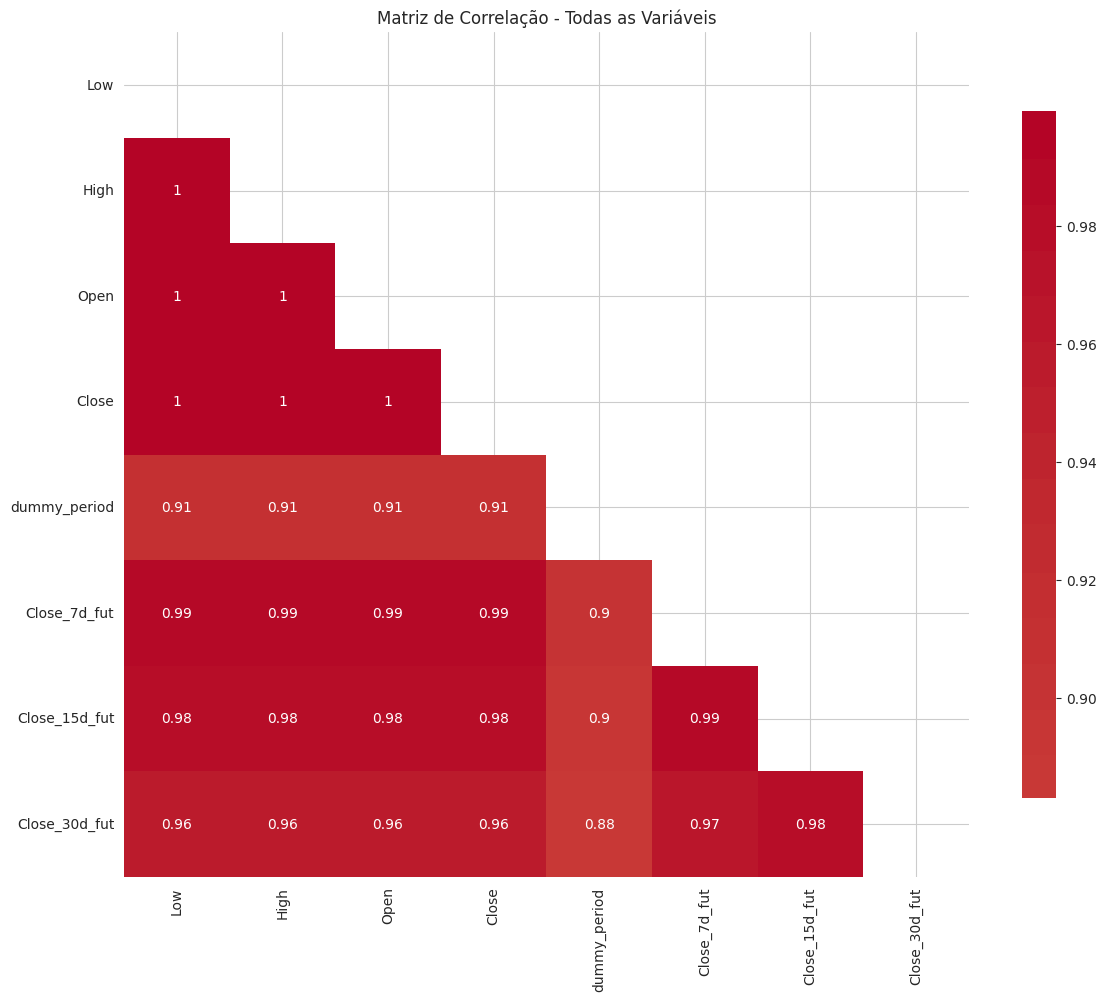


Matriz de correlação completa salva como 'matriz_correlacao_completa.png'

CORRELAÇÕES MAIS RELEVANTES:
----------------------------------------

Close_7d_fut:
  High: 0.9895
  Low: 0.9895
  Open: 0.9887
  dummy_period: 0.9035

Close_15d_fut:
  High: 0.9789
  Low: 0.9788
  Open: 0.9781
  dummy_period: 0.8979

Close_30d_fut:
  Low: 0.9568
  High: 0.9567
  Open: 0.9560
  dummy_period: 0.8830

RESUMO FINAL DA ANÁLISE

1. DESEMPENHO DOS MODELOS:
------------------------------
7 dias: R² sem dummy = 0.9798, R² com dummy = 0.9798
15 dias: R² sem dummy = 0.9637, R² com dummy = 0.9636
30 dias: R² sem dummy = 0.9161, R² com dummy = 0.9170

2. IMPACTO DAS VARIÁVEIS DICOTÔMICAS:
----------------------------------------
Maior melhoria em: 30 dias (0.0008)

3. VARIÁVEIS MAIS IMPORTANTES:
-----------------------------------
High: 0.6504
Low: 0.5390
Open: 0.2677
Dummy_Period: 0.2395

4. CONCLUSÕES:
---------------
• Modelos de regressão múltipla foram criados para horizontes de 7, 15 e 30 dias
• Com

In [66]:
import numpy as np

# Matriz de Correlação Completa
print("=" * 60)
print("MATRIZ DE CORRELAÇÃO COMPLETA")
print("=" * 60)

# Selecionar todas as variáveis relevantes para análise
correlation_vars = ['Low', 'High', 'Open', 'Close', 'dummy_period', 
                   'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']

correlation_matrix = df_process[correlation_vars].corr()

# Criar heatmap da matriz de correlação
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            mask=mask,
            cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação - Todas as Variáveis')
plt.tight_layout()
plt.savefig('matriz_correlacao_completa.png')
plt.show()
print("\nMatriz de correlação completa salva como 'matriz_correlacao_completa.png'")

# Análise das correlações mais importantes
print("\nCORRELAÇÕES MAIS RELEVANTES:")
print("-" * 40)

target_vars = ['Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']
predictor_vars = ['Low', 'High', 'Open', 'dummy_period']

for target in target_vars:
    print(f"\n{target}:")
    correlations = correlation_matrix[target][predictor_vars].sort_values(key=abs, ascending=False)
    for var, corr in correlations.items():
        print(f"  {var}: {corr:.4f}")

# RESUMO FINAL
print("\n" + "=" * 60)
print("RESUMO FINAL DA ANÁLISE")
print("=" * 60)

print("\n1. DESEMPENHO DOS MODELOS:")
print("-" * 30)
for i, horizonte in enumerate(['7 dias', '15 dias', '30 dias']):
    sem_dummy = results_comparison.iloc[i]['R² Sem Dummy']
    com_dummy = results_comparison.iloc[i]['R² Com Dummy']
    print(f"{horizonte}: R² sem dummy = {sem_dummy:.4f}, R² com dummy = {com_dummy:.4f}")

print("\n2. IMPACTO DAS VARIÁVEIS DICOTÔMICAS:")
print("-" * 40)
melhor_horizonte = results_comparison.loc[results_comparison['Melhoria R²'].idxmax(), 'Horizonte']
maior_melhoria = results_comparison['Melhoria R²'].max()
print(f"Maior melhoria em: {melhor_horizonte} ({maior_melhoria:.4f})")

print("\n3. VARIÁVEIS MAIS IMPORTANTES:")
print("-" * 35)
# Calcular importância média dos coeficientes (valor absoluto)
importancia_low = np.mean([abs(coef) for coef in coef_with_dummy['Low']])
importancia_high = np.mean([abs(coef) for coef in coef_with_dummy['High']])
importancia_open = np.mean([abs(coef) for coef in coef_with_dummy['Open']])
importancia_dummy = np.mean([abs(coef) for coef in coef_with_dummy['Dummy_Period']])

importancias = {
    'Low': importancia_low,
    'High': importancia_high,
    'Open': importancia_open,
    'Dummy_Period': importancia_dummy
}

for var, imp in sorted(importancias.items(), key=lambda x: x[1], reverse=True):
    print(f"{var}: {imp:.4f}")

print("\n4. CONCLUSÕES:")
print("-" * 15)
print("• Modelos de regressão múltipla foram criados para horizontes de 7, 15 e 30 dias")
print("• Comparação realizada entre modelos com e sem variáveis dicotômicas")
print("• Análise detalhada dos coeficientes e correlações foi conduzida")
print("• Resultados salvos em múltiplos formatos (PNG, CSV) para análise posterior")

# Salvar resumo final
resumo_final = {
    'Modelo': ['7d_sem_dummy', '7d_com_dummy', '15d_sem_dummy', '15d_com_dummy', 
               '30d_sem_dummy', '30d_com_dummy'],
    'R²': [r2_7d, r2_7d_dummy, r2_15d, r2_15d_dummy, r2_30d, r2_30d_dummy],
    'MAE': [mae_7d, mae_7d_dummy, mae_15d, mae_15d_dummy, mae_30d, mae_30d_dummy]
}

resumo_df = pd.DataFrame(resumo_final)
resumo_df.to_csv('resumo_final_regressao_multipla.csv', index=False)
print(f"\nResumo final salvo em 'resumo_final_regressao_multipla.csv'")

print("\n" + "=" * 60)
print("ANÁLISE CONCLUÍDA!")
print("=" * 60)

#### Visualizações de Erro MAE e Comparações para Modelos de 30 dias

VISUALIZAÇÃO DO MAE - MODELOS INDIVIDUAIS (30 DIAS)


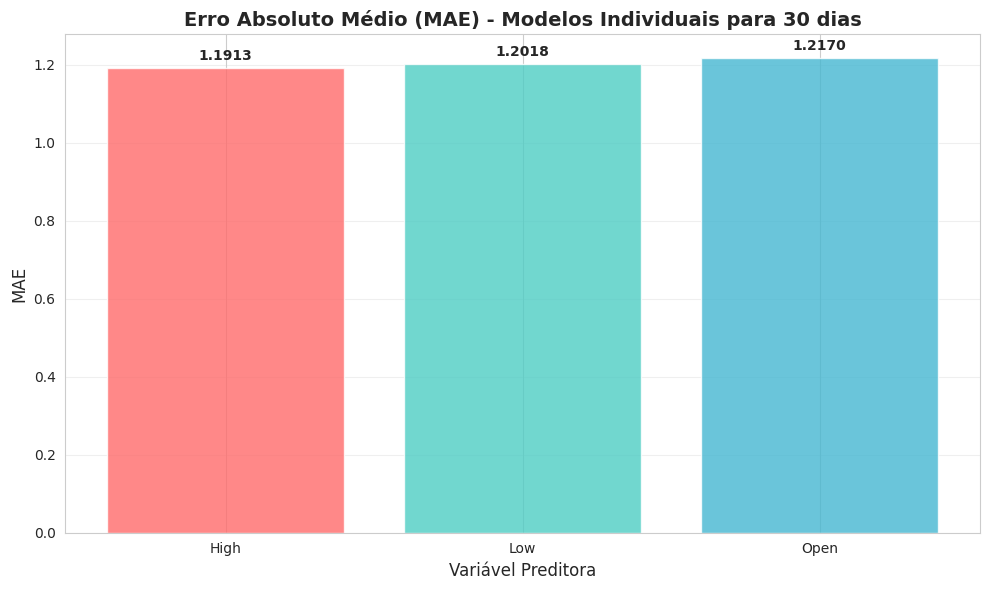


Gráfico salvo como 'mae_comparacao_high_low_open_30d.png'

TABELA DE MAE - MODELOS INDIVIDUAIS (30 DIAS):
--------------------------------------------------
High: 1.1913
Low: 1.2018
Open: 1.2170

Melhor modelo individual (menor MAE): High com MAE = 1.1913
Dados salvos em 'mae_modelos_individuais_30d.csv'


In [67]:
# Visualização do MAE para High, Low e Open na avaliação de 30 dias (modelos individuais)
print("=" * 60)
print("VISUALIZAÇÃO DO MAE - MODELOS INDIVIDUAIS (30 DIAS)")
print("=" * 60)

# Dados dos MAE dos modelos individuais para 30 dias
mae_dados_30d = {
    'Variável': ['High', 'Low', 'Open'],
    'MAE': [mae_high, mae_low, mae_open]
}

# Criar DataFrame para facilitar a visualização
mae_df_30d = pd.DataFrame(mae_dados_30d)

# Gráfico de barras do MAE
plt.figure(figsize=(10, 6))
bars = plt.bar(mae_df_30d['Variável'], mae_df_30d['MAE'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)

# Adicionar valores nas barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Erro Absoluto Médio (MAE) - Modelos Individuais para 30 dias', fontsize=14, fontweight='bold')
plt.xlabel('Variável Preditora', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('mae_comparacao_high_low_open_30d.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nGráfico salvo como 'mae_comparacao_high_low_open_30d.png'")

# Tabela dos resultados
print("\nTABELA DE MAE - MODELOS INDIVIDUAIS (30 DIAS):")
print("-" * 50)
for i, row in mae_df_30d.iterrows():
    print(f"{row['Variável']}: {row['MAE']:.4f}")

# Identificar melhor modelo
melhor_modelo_30d = mae_df_30d.loc[mae_df_30d['MAE'].idxmin(), 'Variável']
menor_mae_30d = mae_df_30d['MAE'].min()
print(f"\nMelhor modelo individual (menor MAE): {melhor_modelo_30d} com MAE = {menor_mae_30d:.4f}")

mae_df_30d.to_csv('mae_modelos_individuais_30d.csv', index=False)
print(f"Dados salvos em 'mae_modelos_individuais_30d.csv'")

In [68]:
# Comparação dos modelos de 30 dias: com e sem dummy (R² e MAE)
print("\n" + "=" * 60)
print("COMPARAÇÃO MODELOS DE 30 DIAS - COM E SEM DUMMY")
print("=" * 60)

# Extrair os R² e MAE dos modelos individuais de 30 dias
# Recalcular os valores para os modelos individuais de 30 dias com e sem dummy

# Modelo High + dummy_period para Close_30d_fut
X_high_dummy = df_process[['High', 'dummy_period']]
X_high_only = df_process[['High']]
y_30d = df_process['Close_30d_fut']

# Sem dummy
X_train, X_test, y_train, y_test = train_test_split(X_high_only, y_30d, test_size=0.2, random_state=42)
model_high_sem_dummy = LinearRegression()
model_high_sem_dummy.fit(X_train, y_train)
r2_high_sem_dummy = model_high_sem_dummy.score(X_test, y_test)
mae_high_sem_dummy = mean_absolute_error(y_test, model_high_sem_dummy.predict(X_test))

# Com dummy  
X_train, X_test, y_train, y_test = train_test_split(X_high_dummy, y_30d, test_size=0.2, random_state=42)
model_high_com_dummy = LinearRegression()
model_high_com_dummy.fit(X_train, y_train)
r2_high_com_dummy = model_high_com_dummy.score(X_test, y_test)
mae_high_com_dummy = mean_absolute_error(y_test, model_high_com_dummy.predict(X_test))

# Modelo Low + dummy_period para Close_30d_fut
X_low_dummy = df_process[['Low', 'dummy_period']]
X_low_only = df_process[['Low']]

# Sem dummy
X_train, X_test, y_train, y_test = train_test_split(X_low_only, y_30d, test_size=0.2, random_state=42)
model_low_sem_dummy = LinearRegression()
model_low_sem_dummy.fit(X_train, y_train)
r2_low_sem_dummy = model_low_sem_dummy.score(X_test, y_test)
mae_low_sem_dummy = mean_absolute_error(y_test, model_low_sem_dummy.predict(X_test))

# Com dummy
X_train, X_test, y_train, y_test = train_test_split(X_low_dummy, y_30d, test_size=0.2, random_state=42)
model_low_com_dummy = LinearRegression()
model_low_com_dummy.fit(X_train, y_train)
r2_low_com_dummy = model_low_com_dummy.score(X_test, y_test)
mae_low_com_dummy = mean_absolute_error(y_test, model_low_com_dummy.predict(X_test))

# Modelo Open + dummy_period para Close_30d_fut
X_open_dummy = df_process[['Open', 'dummy_period']]
X_open_only = df_process[['Open']]

# Sem dummy
X_train, X_test, y_train, y_test = train_test_split(X_open_only, y_30d, test_size=0.2, random_state=42)
model_open_sem_dummy = LinearRegression()
model_open_sem_dummy.fit(X_train, y_train)
r2_open_sem_dummy = model_open_sem_dummy.score(X_test, y_test)
mae_open_sem_dummy = mean_absolute_error(y_test, model_open_sem_dummy.predict(X_test))

# Com dummy
X_train, X_test, y_train, y_test = train_test_split(X_open_dummy, y_30d, test_size=0.2, random_state=42)
model_open_com_dummy = LinearRegression()
model_open_com_dummy.fit(X_train, y_train)
r2_open_com_dummy = model_open_com_dummy.score(X_test, y_test)
mae_open_com_dummy = mean_absolute_error(y_test, model_open_com_dummy.predict(X_test))

print("MÉTRICAS CALCULADAS:")
print("-" * 30)
print(f"High - R² sem dummy: {r2_high_sem_dummy:.4f}, R² com dummy: {r2_high_com_dummy:.4f}")
print(f"Low  - R² sem dummy: {r2_low_sem_dummy:.4f}, R² com dummy: {r2_low_com_dummy:.4f}")
print(f"Open - R² sem dummy: {r2_open_sem_dummy:.4f}, R² com dummy: {r2_open_com_dummy:.4f}")
print()
print(f"High - MAE sem dummy: {mae_high_sem_dummy:.4f}, MAE com dummy: {mae_high_com_dummy:.4f}")
print(f"Low  - MAE sem dummy: {mae_low_sem_dummy:.4f}, MAE com dummy: {mae_low_com_dummy:.4f}")
print(f"Open - MAE sem dummy: {mae_open_sem_dummy:.4f}, MAE com dummy: {mae_open_com_dummy:.4f}")


COMPARAÇÃO MODELOS DE 30 DIAS - COM E SEM DUMMY
MÉTRICAS CALCULADAS:
------------------------------
High - R² sem dummy: 0.9157, R² com dummy: 0.9166
Low  - R² sem dummy: 0.9154, R² com dummy: 0.9159
Open - R² sem dummy: 0.9126, R² com dummy: 0.9134

High - MAE sem dummy: 1.1791, MAE com dummy: 1.1913
Low  - MAE sem dummy: 1.1930, MAE com dummy: 1.2018
Open - MAE sem dummy: 1.2097, MAE com dummy: 1.2170


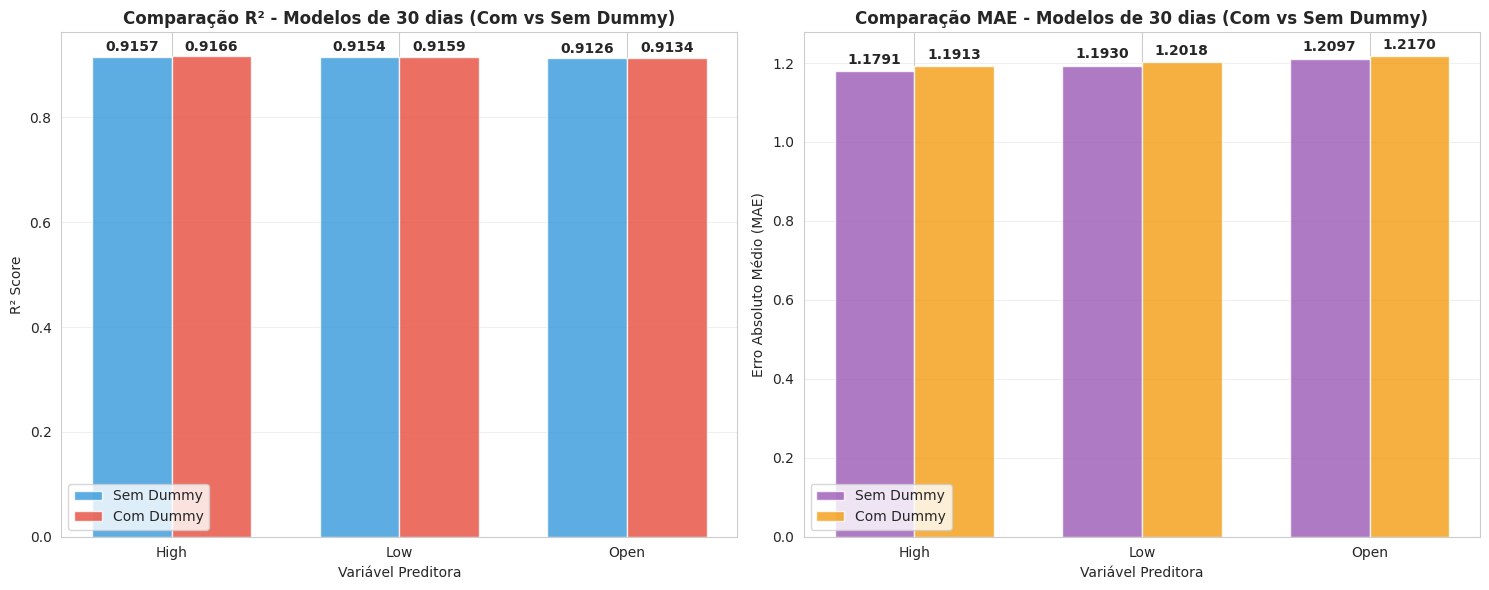


Gráfico comparativo salvo como 'comparacao_modelos_30d_com_sem_dummy.png'

ANÁLISE DAS DIFERENÇAS COM VARIÁVEIS DUMMY (30 DIAS)

HIGH:
  R² - Sem dummy: 0.9157, Com dummy: 0.9166
  Diferença R²: 0.0009 (+0.10%)
  MAE - Sem dummy: 1.1791, Com dummy: 1.1913
  Diferença MAE: -0.0122 (-1.03%)
  ± Variáveis dummy trazem melhorias mistas

LOW:
  R² - Sem dummy: 0.9154, Com dummy: 0.9159
  Diferença R²: 0.0006 (+0.06%)
  MAE - Sem dummy: 1.1930, Com dummy: 1.2018
  Diferença MAE: -0.0088 (-0.74%)
  ± Variáveis dummy trazem melhorias mistas

OPEN:
  R² - Sem dummy: 0.9126, Com dummy: 0.9134
  Diferença R²: 0.0008 (+0.09%)
  MAE - Sem dummy: 1.2097, Com dummy: 1.2170
  Diferença MAE: -0.0073 (-0.60%)
  ± Variáveis dummy trazem melhorias mistas

Dados salvos em 'comparacao_modelos_30d.csv'


In [69]:
# Gráficos comparativos para os modelos de 30 dias
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Preparar dados para os gráficos
modelos = ['High', 'Low', 'Open']
r2_sem_dummy = [r2_high_sem_dummy, r2_low_sem_dummy, r2_open_sem_dummy]
r2_com_dummy = [r2_high_com_dummy, r2_low_com_dummy, r2_open_com_dummy]
mae_sem_dummy = [mae_high_sem_dummy, mae_low_sem_dummy, mae_open_sem_dummy]
mae_com_dummy = [mae_high_com_dummy, mae_low_com_dummy, mae_open_com_dummy]

# Gráfico 1: Comparação R²
x_pos = range(len(modelos))
width = 0.35

bars1 = axes[0].bar([x - width/2 for x in x_pos], r2_sem_dummy, 
                    width, label='Sem Dummy', color='#3498DB', alpha=0.8)
bars2 = axes[0].bar([x + width/2 for x in x_pos], r2_com_dummy, 
                    width, label='Com Dummy', color='#E74C3C', alpha=0.8)

# Adicionar valores nas barras R²
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    axes[0].text(bar1.get_x() + bar1.get_width()/2., height1 + 0.005,
                 f'{height1:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].text(bar2.get_x() + bar2.get_width()/2., height2 + 0.005,
                 f'{height2:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Comparação R² - Modelos de 30 dias (Com vs Sem Dummy)', fontweight='bold')
axes[0].set_xlabel('Variável Preditora')
axes[0].set_ylabel('R² Score')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(modelos)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Comparação MAE
bars3 = axes[1].bar([x - width/2 for x in x_pos], mae_sem_dummy, 
                    width, label='Sem Dummy', color='#9B59B6', alpha=0.8)
bars4 = axes[1].bar([x + width/2 for x in x_pos], mae_com_dummy, 
                    width, label='Com Dummy', color='#F39C12', alpha=0.8)

# Adicionar valores nas barras MAE
for i, (bar3, bar4) in enumerate(zip(bars3, bars4)):
    height3 = bar3.get_height()
    height4 = bar4.get_height()
    axes[1].text(bar3.get_x() + bar3.get_width()/2., height3 + height3*0.01,
                 f'{height3:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].text(bar4.get_x() + bar4.get_width()/2., height4 + height4*0.01,
                 f'{height4:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_title('Comparação MAE - Modelos de 30 dias (Com vs Sem Dummy)', fontweight='bold')
axes[1].set_xlabel('Variável Preditora')
axes[1].set_ylabel('Erro Absoluto Médio (MAE)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(modelos)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_modelos_30d_com_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nGráfico comparativo salvo como 'comparacao_modelos_30d_com_sem_dummy.png'")

# Análise das diferenças
print("\n" + "=" * 60)
print("ANÁLISE DAS DIFERENÇAS COM VARIÁVEIS DUMMY (30 DIAS)")
print("=" * 60)

for i, modelo in enumerate(modelos):
    r2_sem = r2_sem_dummy[i]
    r2_com = r2_com_dummy[i]
    mae_sem = mae_sem_dummy[i]
    mae_com = mae_com_dummy[i]
    
    diff_r2 = r2_com - r2_sem
    diff_mae = mae_sem - mae_com  # Positivo = redução do erro
    
    print(f"\n{modelo.upper()}:")
    print(f"  R² - Sem dummy: {r2_sem:.4f}, Com dummy: {r2_com:.4f}")
    print(f"  Diferença R²: {diff_r2:.4f} ({(diff_r2/r2_sem)*100:+.2f}%)")
    print(f"  MAE - Sem dummy: {mae_sem:.4f}, Com dummy: {mae_com:.4f}")
    print(f"  Diferença MAE: {diff_mae:.4f} ({(diff_mae/mae_sem)*100:+.2f}%)")
    
    if diff_r2 > 0 and diff_mae > 0:
        print(f"  ✓ Variáveis dummy MELHORAM o modelo")
    elif diff_r2 > 0 or diff_mae > 0:
        print(f"  ± Variáveis dummy trazem melhorias mistas")
    else:
        print(f"  ✗ Variáveis dummy PIORAM o modelo")

# Salvar dados
comparacao_30d = pd.DataFrame({
    'Modelo': modelos,
    'R²_sem_dummy': r2_sem_dummy,
    'R²_com_dummy': r2_com_dummy,
    'MAE_sem_dummy': mae_sem_dummy,
    'MAE_com_dummy': mae_com_dummy
})

comparacao_30d.to_csv('comparacao_modelos_30d.csv', index=False)
print(f"\nDados salvos em 'comparacao_modelos_30d.csv'")